# Tile Pricing — Multimodal Ablation & Final Submission
This notebook runs **both** models (tabular-only and tabular + CLIP vision) side by side, compares their cross-validation performance, and automatically generates the submission from whichever model performs better.

In [9]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import shap
import matplotlib.pyplot as plt
import os

## Step 1 — Load All Data

In [10]:
# Tabular features
train_df = pd.read_pickle('../outputs/train_processed.pkl')
test_df  = pd.read_pickle('../outputs/test_processed.pkl')

# CLIP image embeddings
clip_embeddings = np.load('../embeddings/clip_embeddings.npy')
clip_sku_ids    = np.load('../embeddings/clip_sku_ids.npy', allow_pickle=True)

print(f'Tabular — Train: {train_df.shape}, Test: {test_df.shape}')
print(f'CLIP    — Embeddings: {clip_embeddings.shape}, IDs: {clip_sku_ids.shape}')

Tabular — Train: (2272, 113), Test: (568, 111)
CLIP    — Embeddings: (2840, 512), IDs: (2840,)


## Step 2 — PCA on Image Embeddings

In [11]:
emb_lookup = dict(zip(clip_sku_ids, clip_embeddings))

train_emb = np.array([emb_lookup.get(sid, np.zeros(512)) for sid in train_df['sku_id'].values])
test_emb  = np.array([emb_lookup.get(sid, np.zeros(512)) for sid in test_df['sku_id'].values])

n_components = 50
pca = PCA(n_components=n_components, random_state=42)
pca.fit(np.vstack([train_emb, test_emb]))

train_pca = pca.transform(train_emb)
test_pca  = pca.transform(test_emb)

print(f'PCA explained variance (50 components): {pca.explained_variance_ratio_.sum():.2%}')

PCA explained variance (50 components): 84.90%


## Step 3 — Build Feature Matrices

In [12]:
numeric_features = [
    'tile_volume_mm3', 'tile_area_mm2', 'aspect_ratio',
    'product_width_val', 'product_length_val', 'product_thickness_val',
    'pieces_per_box_num', 'boxes_per_pallet_num', 'area_per_box_val',
    'box_weight_val', 'area_per_pallet_val', 'loaded_pallet_weight_val',
    'breaking_strength_val', 'modulus_of_rupture_val', 'water_absorption_rate_val',
    'mohs_surface_hardness_val', 'dcof_value', 'pei_value',
    'r_rating_val', 'pendulum_val', 'barefoot_val',
    'is_glazed_int',
    'collection_mean_price', 'collection_std_price', 'collection_count', 'collection_mean_log_price',
    'pei_value_is_missing', 'dcof_value_is_missing', 'mohs_surface_hardness_val_is_missing',
    'water_absorption_rate_val_is_missing', 'breaking_strength_val_is_missing',
    'modulus_of_rupture_val_is_missing', 'r_rating_val_is_missing',
    'barefoot_val_is_missing', 'pendulum_val_is_missing'
]

categorical_features = [
    'finish_keyword', 'body_type', 'shade_variation_rating', 'edge_type',
    'finish_type', 'subcategory', 'app_combo', 'piece_type'
]

pca_features = [f'clip_pca_{i}' for i in range(n_components)]

# Label-encode categoricals
combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
for col in categorical_features:
    combined[col] = combined[col].astype(str)
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col])

train_tab = combined.iloc[:len(train_df)][numeric_features + categorical_features].copy()
test_tab  = combined.iloc[len(train_df):][numeric_features + categorical_features].copy()

# TABULAR-ONLY matrices
X_train_tab = train_tab.fillna(-999)
X_test_tab  = test_tab.fillna(-999)

# MULTIMODAL matrices (tabular + PCA vision)
train_multi = train_tab.copy()
test_multi  = test_tab.copy()
for i, col_name in enumerate(pca_features):
    train_multi[col_name] = train_pca[:, i]
    test_multi[col_name]  = test_pca[:, i]

X_train_multi = train_multi.fillna(-999)
X_test_multi  = test_multi.fillna(-999)

y_train = train_df['log_price'].values
y_true  = train_df['price_usd_per_sqm'].values

print(f'Tabular-only features: {X_train_tab.shape[1]}')
print(f'Multimodal features:   {X_train_multi.shape[1]}')

Tabular-only features: 43
Multimodal features:   93


## Step 4 — Train Both Models (5-Fold CV)

In [13]:
def run_cv(X_train, X_test, y_train_log, tag='Model'):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    oof = np.zeros(len(X_train))
    test_preds = np.zeros(len(X_test))
    models = []

    xgb_params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'learning_rate': 0.05,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42
    }

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train)):
        dtrain = xgb.DMatrix(X_train.iloc[tr_idx], label=y_train_log[tr_idx])
        dval   = xgb.DMatrix(X_train.iloc[va_idx], label=y_train_log[va_idx])
        dtest  = xgb.DMatrix(X_test)

        model = xgb.train(
            xgb_params, dtrain,
            num_boost_round=1000,
            evals=[(dval, 'val')],
            early_stopping_rounds=50,
            verbose_eval=0   # silent — we only care about final metrics
        )
        models.append(model)
        oof[va_idx] = model.predict(dval)
        test_preds += model.predict(dtest) / kf.n_splits

    oof_actual = np.exp(oof)
    mae = mean_absolute_error(y_true, oof_actual)
    rmse = np.sqrt(mean_squared_error(y_train_log, oof))
    pct10 = np.mean(np.abs(y_true - oof_actual) / y_true <= 0.10) * 100
    pct20 = np.mean(np.abs(y_true - oof_actual) / y_true <= 0.20) * 100

    print(f'\n=== {tag} ===')
    print(f'  MAE (Actual $):        ${mae:.2f}')
    print(f'  RMSE (Log Scale):      {rmse:.4f}')
    print(f'  Within ±10% of True:   {pct10:.1f}%')
    print(f'  Within ±20% of True:   {pct20:.1f}%')

    return {'mae': mae, 'rmse': rmse, 'pct10': pct10, 'pct20': pct20,
            'test_preds': test_preds, 'models': models, 'oof': oof}

print('Training tabular-only model...')
tab_result = run_cv(X_train_tab, X_test_tab, y_train, tag='Tabular Only')

print('\nTraining multimodal model...')
multi_result = run_cv(X_train_multi, X_test_multi, y_train, tag='Tabular + Vision')

Training tabular-only model...

=== Tabular Only ===
  MAE (Actual $):        $0.11
  RMSE (Log Scale):      0.0340
  Within ±10% of True:   98.5%
  Within ±20% of True:   99.5%

Training multimodal model...

=== Tabular + Vision ===
  MAE (Actual $):        $0.28
  RMSE (Log Scale):      0.0404
  Within ±10% of True:   97.8%
  Within ±20% of True:   99.3%


## Step 5 — Side-by-Side Comparison

In [14]:
print('\n' + '='*60)
print(f'{"Metric":<30} {"Tabular Only":>14} {"+ Vision":>14}')
print('='*60)
print(f'{"MAE (Actual $)":<30} ${tab_result["mae"]:>12.2f}  ${multi_result["mae"]:>12.2f}')
print(f'{"RMSE (Log Scale)":<30} {tab_result["rmse"]:>13.4f}  {multi_result["rmse"]:>13.4f}')
print(f'{"Within ±10%":<30} {tab_result["pct10"]:>12.1f}%  {multi_result["pct10"]:>12.1f}%')
print(f'{"Within ±20%":<30} {tab_result["pct20"]:>12.1f}%  {multi_result["pct20"]:>12.1f}%')
print('='*60)

# Pick the better model
if tab_result['mae'] <= multi_result['mae']:
    best = tab_result
    best_name = 'Tabular Only'
else:
    best = multi_result
    best_name = 'Tabular + Vision'

print(f'\n→ Best model: {best_name} (lower MAE)')


Metric                           Tabular Only       + Vision
MAE (Actual $)                 $        0.11  $        0.28
RMSE (Log Scale)                      0.0340         0.0404
Within ±10%                            98.5%          97.8%
Within ±20%                            99.5%          99.3%

→ Best model: Tabular Only (lower MAE)


## Step 6 — SHAP Feature Importance (Best Model)

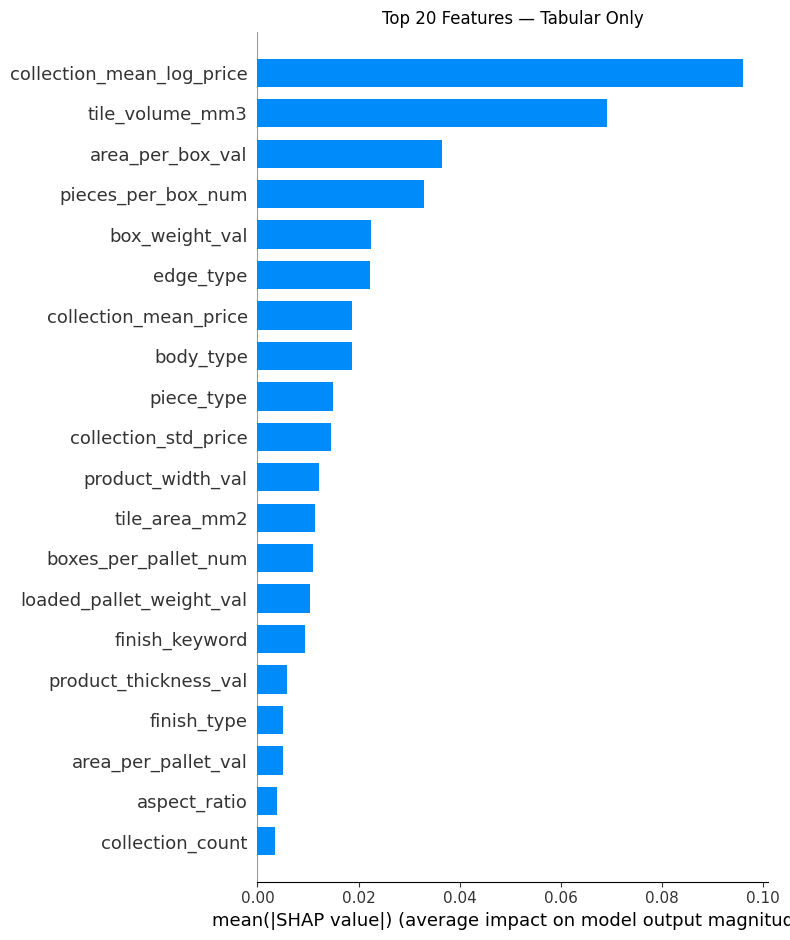

In [15]:
# Pick the right feature matrix for the best model
if best_name == 'Tabular Only':
    X_shap = X_train_tab
else:
    X_shap = X_train_multi

dtrain_shap = xgb.DMatrix(X_shap)
shap_matrix = best['models'][-1].predict(dtrain_shap, pred_contribs=True)
shap_vals = shap_matrix[:, :-1]

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_shap, plot_type='bar', max_display=20, show=False)
plt.title(f'Top 20 Features — {best_name}')
plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/shap_final.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Generate Final Submission

In [16]:
test_preds_actual = np.exp(best['test_preds'])

submission = pd.DataFrame({
    'sku_id': test_df['sku_id'].values,
    'price_usd_per_sqm': test_preds_actual
})

print(f'Submission shape: {submission.shape}')
print(f'Price range: ${submission["price_usd_per_sqm"].min():.2f} – ${submission["price_usd_per_sqm"].max():.2f}')
print(f'Mean price:  ${submission["price_usd_per_sqm"].mean():.2f}')
print(f'\nUsing: {best_name}')
print(submission.head(10))

submission.to_csv('../outputs/submission.csv', index=False)
print(f'\nSaved to outputs/submission.csv  ({len(submission)} rows)')

Submission shape: (568, 2)
Price range: $5.95 – $33.56
Mean price:  $13.89

Using: Tabular Only
               sku_id  price_usd_per_sqm
0  300000000000072252          18.930148
1  300000000000042715          19.180334
2  300000000000045241           9.459891
3  300000000000042706          19.190973
4  300000000000049018          11.805045
5  300000000000056211          11.813123
6  300000000000045345          14.000213
7  300000000000042226          15.159822
8  300000000000063907          14.028346
9  300000000000049647          11.138023

Saved to outputs/submission.csv  (568 rows)
